In [6]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime, timedelta

# إحداثيات القاهرة
LATITUDE = 30.0444
LONGITUDE = 31.2357

# آخر تاريخ بيانات متاحة عادة بيكون بفارق يومين لتلاتة أيام عن النهاردة (NASA POWER latency)
END_DATE = (datetime.today() - timedelta(days=3)).strftime('%Y%m%d')
START_DATE = "20220101"

# بناء رابط الطلب
url = "https://power.larc.nasa.gov/api/temporal/daily/point"
params = {
    "parameters": "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR",
    "community": "AG",
    "longitude": LONGITUDE,
    "latitude": LATITUDE,
    "start": START_DATE,
    "end": END_DATE,
    "format": "JSON"
}

response = requests.get(url, params=params)
print("Status code:", response.status_code)

Status code: 200


In [7]:
data = response.json()

# البيانات جوه properties -> parameter -> اسم كل متغير
weather_data = data['properties']['parameter']

# نحول كل متغير (T2M, T2M_MAX, ...) لعمود في جدول واحد
df = pd.DataFrame(weather_data)

df.shape

(1684, 4)

In [8]:
# تسمية الأعمدة بأسماء أوضح
df = df.rename(columns={
    'T2M': 'temperature_mean',
    'T2M_MAX': 'temperature_max',
    'T2M_MIN': 'temperature_min',
    'PRECTOTCORR': 'precipitation'
})

# تحويل الـ index (التاريخ) من نص لـ datetime
df.index = pd.to_datetime(df.index, format='%Y%m%d')
df.index.name = 'date'

df.head()

,temperature_mean,temperature_max,temperature_min,precipitation
date,,,,
2022-01-01,12.20,18.29,7.63,0.51
2022-01-02,12.18,18.83,6.79,0.33
2022-01-03,12.91,19.76,8.35,0.40
2022-01-04,12.02,18.59,7.90,0.15
2022-01-05,12.67,19.56,7.71,0.00


In [9]:
# استبدال -999 (قيمة NASA POWER لـ missing/غير مؤكدة) بـ NaN
df = df.replace(-999.0, np.nan)
df = df.replace(-999, np.nan)

print("Missing values per column after replacing -999:")
print(df.isna().sum())

# لو آخر صف (أو أكتر) فاضي بالكامل، اقطعه قبل أي حاجة
df = df.dropna(how='all')

print("\nShape after dropping fully-empty trailing rows:", df.shape)
print("New last date:", df.index.max())

Missing values per column after replacing -999:
temperature_mean    0
temperature_max     0
temperature_min     0
precipitation       0
dtype: int64

Shape after dropping fully-empty trailing rows: (1684, 4)
New last date: 2026-08-11 00:00:00


In [10]:
# حفظ الرد الخام (JSON) زي ما هو
with open('cairo_weather_raw.json', 'w') as f:
    json.dump(data, f)

# حفظ الجدول المنظم (لسه من غير تنظيف) كملف مبدئي
df.to_csv(f'cairo_weather_{START_DATE[:4]}_{END_DATE[:4]}_initial.csv')

print("Raw JSON and initial CSV saved.")

Raw JSON and initial CSV saved.


## Data Source Documentation

- **API:** NASA POWER (Daily Point API) — free, no API key required
- **Endpoint:** `https://power.larc.nasa.gov/api/temporal/daily/point`
- **Parameters requested:**
  - `T2M`: Mean temperature at 2 meters (°C)
  - `T2M_MAX`: Maximum temperature at 2 meters (°C)
  - `T2M_MIN`: Minimum temperature at 2 meters (°C)
  - `PRECTOTCORR`: Corrected total precipitation (mm/day)
- **Community:** AG (Agroclimatology)
- **Region:** Cairo, Egypt (Latitude: {LATITUDE}, Longitude: {LONGITUDE})
- **Time range:** {df.index.min().date()} to {df.index.max().date()} ({len(df)} daily observations)
- **Reasoning for daily granularity:** Multiple years of daily data capture seasonal
  patterns (summer/winter cycles) which is essential for meaningful time-series EDA,
  while remaining lightweight and fast to retrieve in a single request.
- **Rate limits encountered:** None — the request completed successfully on the first attempt.
"""))

In [11]:
# هل فيه تواريخ مكررة؟
print("Duplicated timestamps:", df.index.duplicated().sum())

# هل فيه فجوات؟ نقارن عدد الأيام الفعلي بعدد الأيام المتوقع بين أول وآخر تاريخ
expected_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
missing_dates = expected_range.difference(df.index)

print("Expected number of days:", len(expected_range))
print("Actual number of days:", len(df))
print("Missing dates count:", len(missing_dates))
if len(missing_dates) > 0:
    print("Missing dates:", missing_dates.tolist())

Duplicated timestamps: 0
Expected number of days: 1684
Actual number of days: 1684
Missing dates count: 0


In [12]:
# فحص القيم الناقصة العادية (NaN)
print("Missing values per column:")
print(df.isnull().sum())

print("\nSummary statistics:")
print(df.describe())

# فحص القيم المشبوهة (NASA بتستخدم -999 كرمز لـ "بيانات مش متاحة")
suspicious = (df == -999).sum()
print("\nSuspicious (-999) values per column:")
print(suspicious)

Missing values per column:
temperature_mean    0
temperature_max     0
temperature_min     0
precipitation       0
dtype: int64

Summary statistics:
       temperature_mean  temperature_max  temperature_min  precipitation
count       1684.000000      1684.000000      1684.000000    1684.000000
mean          22.343147        30.204252        15.454941       0.286443
std            6.974583         7.676829         5.993994       2.054193
min            6.670000        11.790000         1.140000       0.000000
25%           15.767500        23.057500        10.160000       0.000000
50%           22.820000        30.910000        15.700000       0.000000
75%           29.062500        37.435000        20.920000       0.010000
max           35.050000        45.490000        27.510000      42.540000

Suspicious (-999) values per column:
temperature_mean    0
temperature_max     0
temperature_min     0
precipitation       0
dtype: int64


## Missing Value Strategy

No missing values (NaN) or suspicious sentinel values (e.g. -999, commonly used by NASA
datasets to flag unavailable data) were found in any column. Since the dataset is already
complete with no gaps, no imputation, interpolation, or forward-fill strategy was required.
If missing values had been found, a linear interpolation would have been the appropriate
choice for temperature (a smoothly changing variable), while precipitation gaps would be
better handled with forward-fill or explicit flagging, since rainfall can genuinely be zero
and should not be interpolated the same way as temperature.

In [13]:
# NASA POWER API بترجع دايمًا الحرارة بالـ °C والأمطار بالـ mm/day (موثق رسميًا في الـ API)
# نتأكد بصريًا إن الأرقام منطقية للوحدات دي (مش فارنهايت أو إنش مثلاً)
print("Temperature range (°C):", df['temperature_min'].min(), "to", df['temperature_max'].max())
print("Precipitation range (mm/day):", df['precipitation'].min(), "to", df['precipitation'].max())

Temperature range (°C): 1.14 to 45.49
Precipitation range (mm/day): 0.0 to 42.54


In [14]:
clean_filename = f'cairo_weather_{START_DATE[:4]}_{END_DATE[:4]}_clean.csv'
df.to_csv(clean_filename)
print(f"Clean dataset saved as '{clean_filename}'")
df.info()

Clean dataset saved as 'cairo_weather_2022_2026_clean.csv'
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1684 entries, 2022-01-01 to 2026-08-11
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temperature_mean  1684 non-null   float64
 1   temperature_max   1684 non-null   float64
 2   temperature_min   1684 non-null   float64
 3   precipitation     1684 non-null   float64
dtypes: float64(4)
memory usage: 65.8 KB


In [15]:
# إحصائيات وصفية (شفناها قبل كده، بس نعيدها هنا رسمي كجزء من الـ EDA)
df[['temperature_mean', 'precipitation']].describe()

,temperature_mean,precipitation
count,1684.000000,1684.000000
mean,22.343147,0.286443
std,6.974583,2.054193
min,6.670000,0.000000
25%,15.767500,0.000000
50%,22.820000,0.000000
75%,29.062500,0.010000
max,35.050000,42.540000


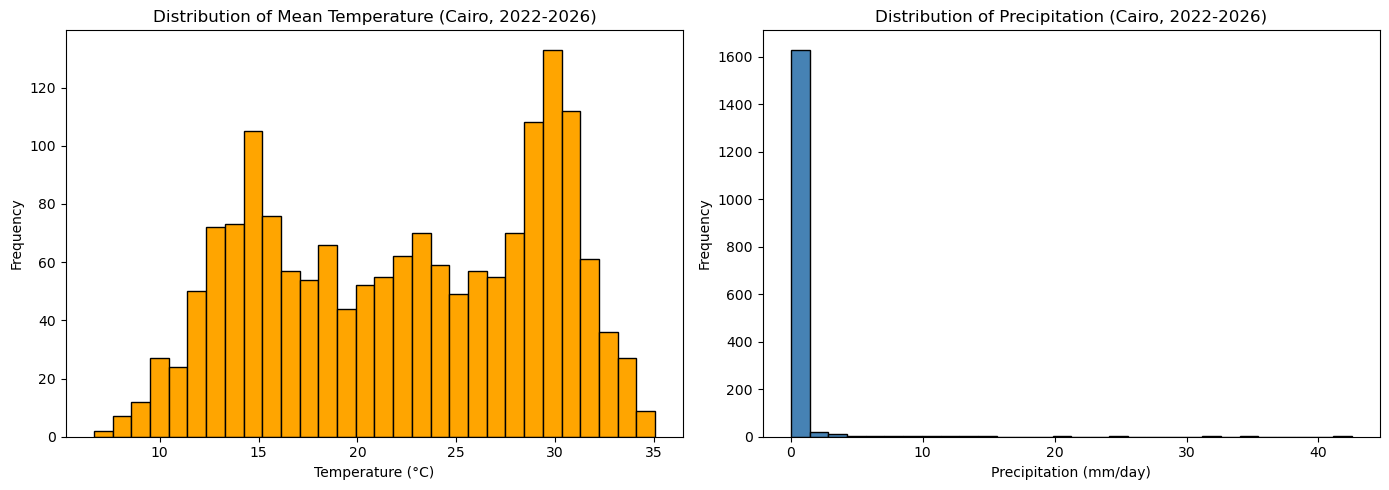

In [16]:
year_range = f"{df.index.min().year}-{df.index.max().year}"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['temperature_mean'], bins=30, color='orange', edgecolor='black')
axes[0].set_title(f'Distribution of Mean Temperature (Cairo, {year_range})')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['precipitation'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title(f'Distribution of Precipitation (Cairo, {year_range})')
axes[1].set_xlabel('Precipitation (mm/day)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('plot1_distributions.png', dpi=100)
plt.show()

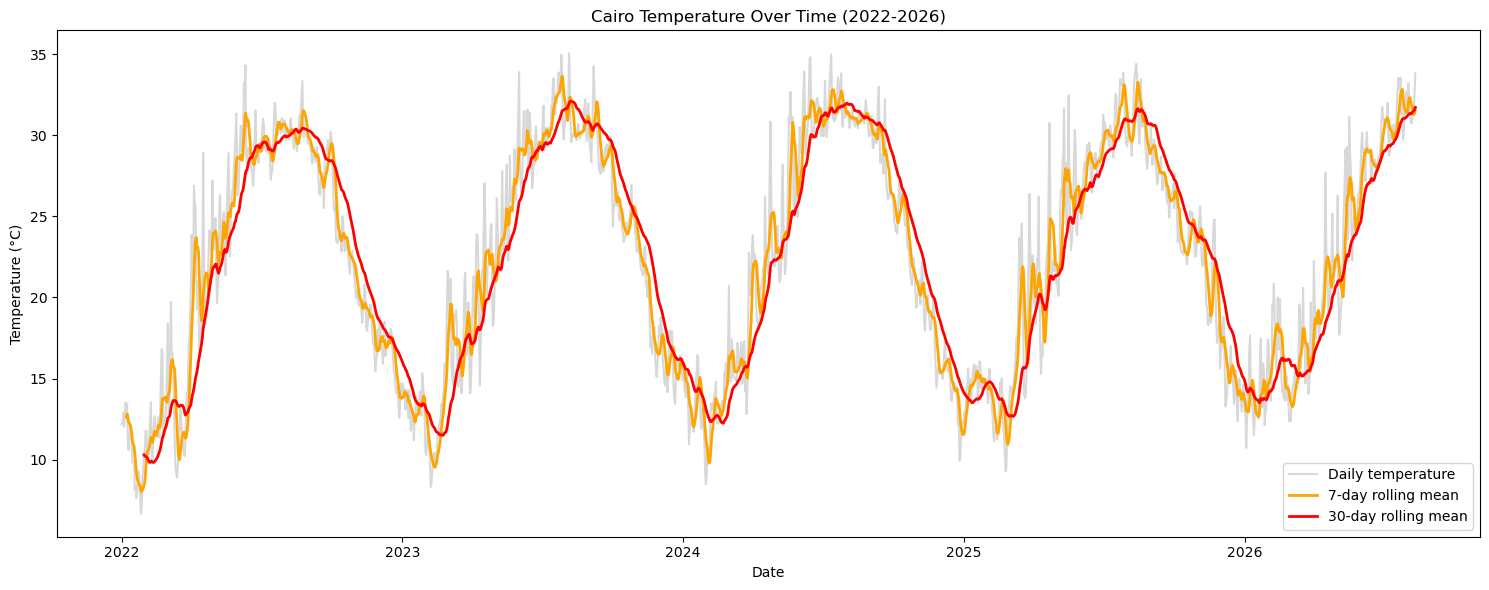

In [17]:
# حساب المتوسط المتحرك (rolling mean) لفترة 7 أيام و30 يوم
df['temp_rolling_7d'] = df['temperature_mean'].rolling(window=7).mean()
df['temp_rolling_30d'] = df['temperature_mean'].rolling(window=30).mean()

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df.index, df['temperature_mean'], alpha=0.3, label='Daily temperature', color='gray')
ax.plot(df.index, df['temp_rolling_7d'], label='7-day rolling mean', color='orange', linewidth=2)
ax.plot(df.index, df['temp_rolling_30d'], label='30-day rolling mean', color='red', linewidth=2)
ax.set_title(f'Cairo Temperature Over Time ({year_range})')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.savefig('plot2_temperature_trend.png', dpi=100)
plt.show()

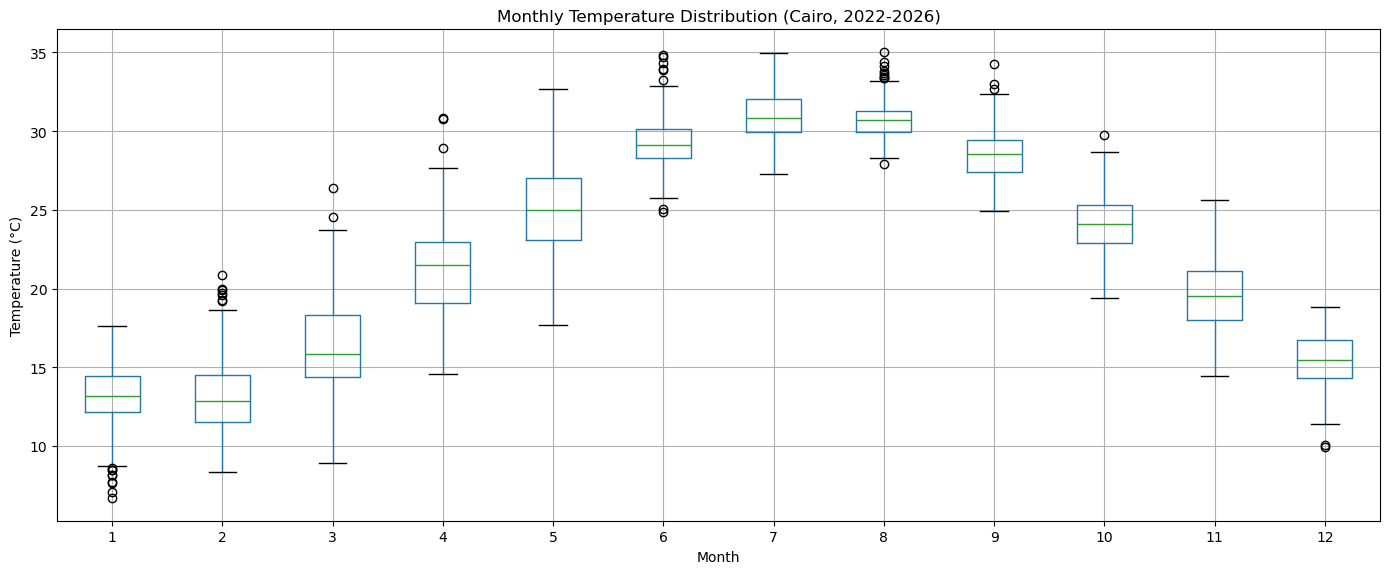

In [18]:
df['month'] = df.index.month
df['month_name'] = df.index.strftime('%b')  # Jan, Feb, ...

fig, ax = plt.subplots(figsize=(14, 6))
df.boxplot(column='temperature_mean', by='month', ax=ax)
ax.set_title(f'Monthly Temperature Distribution (Cairo, {year_range})')
plt.suptitle('')  # يشيل العنوان التلقائي الزيادة اللي بيحطه pandas
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
plt.tight_layout()
plt.savefig('plot3_monthly_boxplot.png', dpi=100)
plt.show()

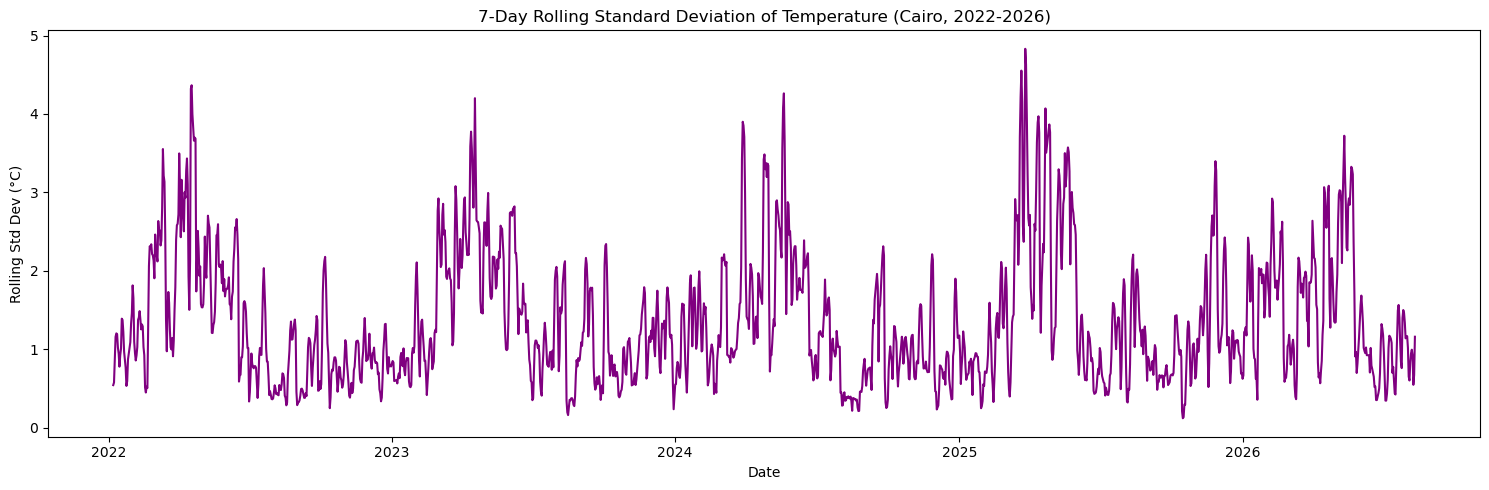

In [19]:
df['temp_rolling_std_7d'] = df['temperature_mean'].rolling(window=7).std()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, df['temp_rolling_std_7d'], color='purple')
ax.set_title(f'7-Day Rolling Standard Deviation of Temperature (Cairo, {year_range})')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Std Dev (°C)')
plt.tight_layout()
plt.savefig('plot4_rolling_std.png', dpi=100)
plt.show()

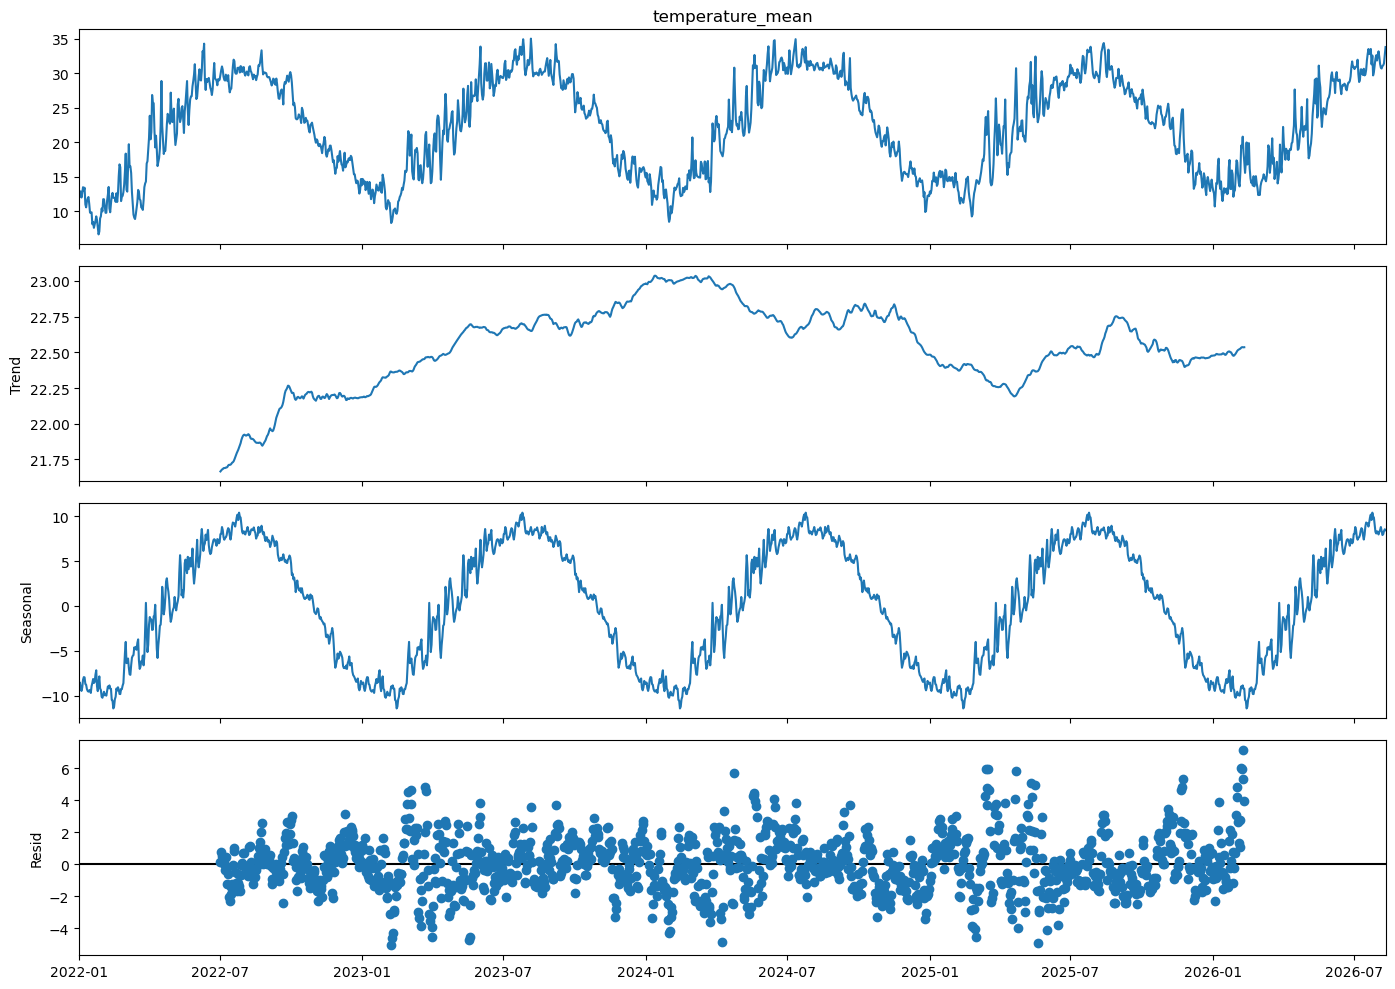

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['temperature_mean'], model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.savefig('plot5_decomposition.png', dpi=100)
plt.show()

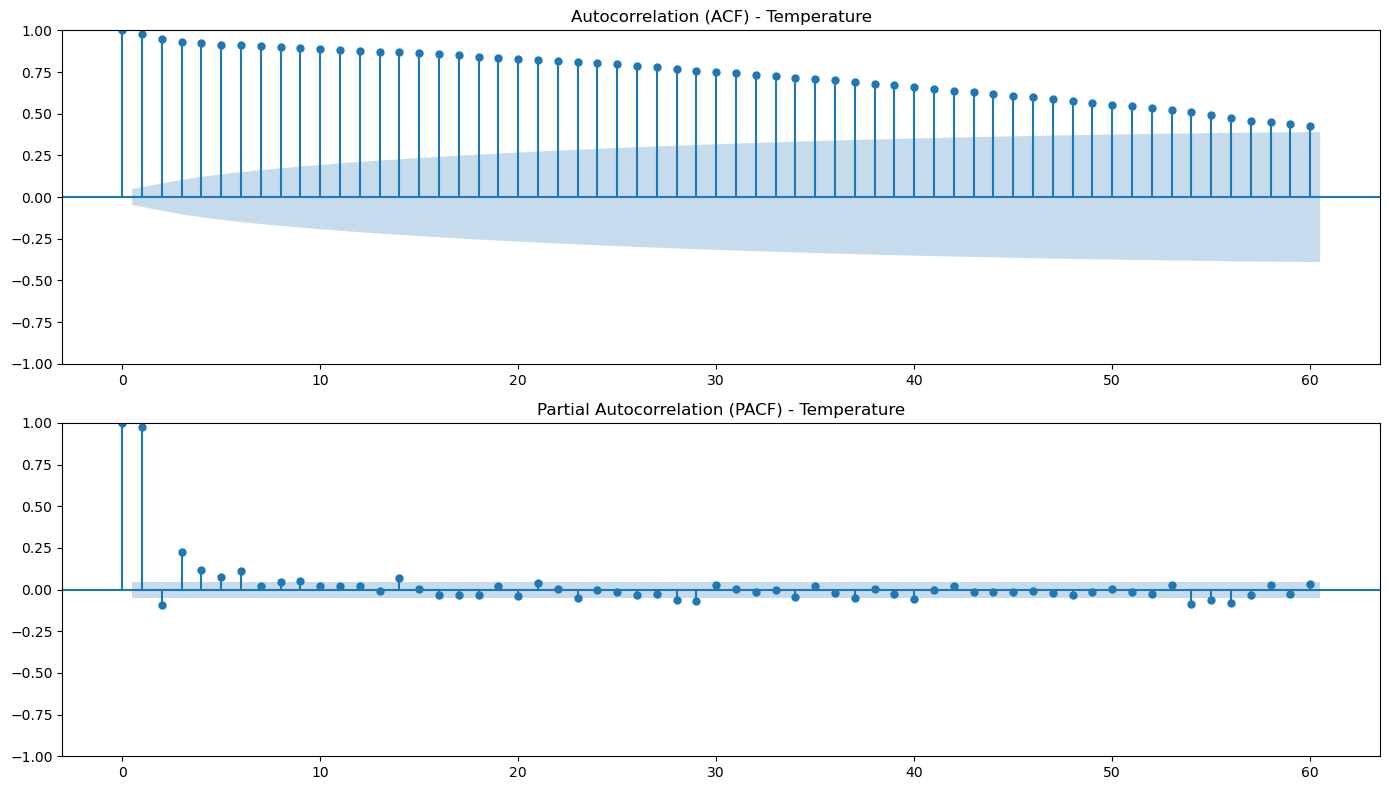

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(df['temperature_mean'], lags=60, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF) - Temperature')

plot_pacf(df['temperature_mean'], lags=60, ax=axes[1])
axes[1].set_title('Partial Autocorrelation (PACF) - Temperature')

plt.tight_layout()
plt.savefig('plot6_acf_pacf.png', dpi=100)
plt.show()

In [22]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['temperature_mean'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

if result[1] <= 0.05:
    print("\n→ Result: The series is likely STATIONARY (reject the null hypothesis)")
else:
    print("\n→ Result: The series is likely NON-STATIONARY (fail to reject the null hypothesis)")

ADF Statistic: -2.0021533340798716
p-value: 0.28562973611331993
Critical Values:
   1%: -3.4342717844184696
   5%: -2.8632722453211117
   10%: -2.567692204811933

→ Result: The series is likely NON-STATIONARY (fail to reject the null hypothesis)


In [23]:
correlation = df[['temperature_mean', 'precipitation']].corr()
print("Correlation matrix:")
print(correlation)

Correlation matrix:
                  temperature_mean  precipitation
temperature_mean          1.000000      -0.142526
precipitation            -0.142526       1.000000


In [24]:
# نستخدم rolling z-score بدل عتبة ثابتة، عشان الصيف والشتا عندهم "طبيعي" مختلف
rolling_mean = df['temperature_mean'].rolling(window=30, center=True).mean()
rolling_std = df['temperature_mean'].rolling(window=30, center=True).std()
df['temp_zscore'] = (df['temperature_mean'] - rolling_mean) / rolling_std

outliers = df[df['temp_zscore'].abs() > 3]
print(f"Number of temperature outliers (|z-score| > 3): {len(outliers)}")
print(outliers[['temperature_mean', 'temp_zscore']])

# فحص قيم مستحيلة فيزيائيًا (أمطار سالبة، حرارة غير منطقية للقاهرة)
impossible = df[(df['precipitation'] < 0) | (df['temperature_mean'] < -10) | (df['temperature_mean'] > 55)]
print(f"\nPhysically impossible values found: {len(impossible)}")

Number of temperature outliers (|z-score| > 3): 3
            temperature_mean  temp_zscore
date                                     
2024-03-01             20.73     3.118942
2024-04-24             30.84     3.187031
2026-04-16             27.68     3.057815

Physically impossible values found: 0


In [25]:
final_filename = f'cairo_weather_{START_DATE[:4]}_{END_DATE[:4]}_analyzed.csv'
df.to_csv(final_filename)
print(f"Final analyzed dataset saved as '{final_filename}'")
df.columns.tolist()

Final analyzed dataset saved as 'cairo_weather_2022_2026_analyzed.csv'


['temperature_mean',
 'temperature_max',
 'temperature_min',
 'precipitation',
 'temp_rolling_7d',
 'temp_rolling_30d',
 'month',
 'month_name',
 'temp_rolling_std_7d',
 'temp_zscore']

In [26]:
print("Min:", df['temperature_mean'].min())
print("Max:", df['temperature_mean'].max())

Min: 6.67
Max: 35.05
